# PyTorch GAN

**Part 1** follows the course: a vanilla GAN (two MLPs) trained on MNIST.

**Part 2** connects it to the real world: the Discriminator we train here *is*
a fake-image detector, which is exactly the problem posed by
[whichfaceisreal.com](https://www.whichfaceisreal.com/) and
[thispersondoesnotexist.com](https://thispersondoesnotexist.com/). We pull real
and GAN-generated faces from those sites and build a working detector for them.

Adapted to run locally on macOS + Apple GPU (MPS) rather than Colab/CUDA.

In [1]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torchvision.utils import save_image
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import os

In [2]:
# looks weird, but makes pixel values between -1 and +1
# assume they are transformed from (0, 1)
# min value = (0 - 0.5) / 0.5 = -1
# max value = (1 - 0.5) / 0.5 = +1
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5,),
                         std=(0.5,))])

In [3]:
train_dataset = torchvision.datasets.MNIST(
    root='.',
    train=True,
    transform=transform,
    download=True)

In [4]:
len(train_dataset)

60000

In [5]:
batch_size = 128
data_loader = torch.utils.data.DataLoader(dataset=train_dataset,
                                          batch_size=batch_size,
                                          shuffle=True)

In [6]:
# Discriminator
D = nn.Sequential(
    nn.Linear(784, 512),
    nn.LeakyReLU(0.2),
    nn.Linear(512, 256),
    nn.LeakyReLU(0.2),
    nn.Linear(256, 1),
    # nn.Sigmoid()
)

Note the `Sigmoid` is commented out. We use `BCEWithLogitsLoss` below, which
applies the sigmoid internally in a numerically stable way, so `D` outputs raw
logits. A logit > 0 means "I think this is real".

In [7]:
# Generator
latent_dim = 100
G = nn.Sequential(
    nn.Linear(latent_dim, 256),
    nn.LeakyReLU(0.2),
    nn.BatchNorm1d(256, momentum=0.7),
    nn.Linear(256, 512),
    nn.LeakyReLU(0.2),
    nn.BatchNorm1d(512, momentum=0.7),
    nn.Linear(512, 1024),
    nn.LeakyReLU(0.2),
    nn.BatchNorm1d(1024, momentum=0.7),
    nn.Linear(1024, 784),
    nn.Tanh()
)

The generator ends with a `Tanh` activation, which maps the output values to be
between -1 and +1 — matching the range our `Normalize` transform produced for the
real images.

In [8]:
# Set device
# Course uses 'cuda'; on Apple Silicon we prefer MPS and fall back to CPU.
device = torch.device("mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu"))
print(device)
D = D.to(device)
G = G.to(device)

mps


In [9]:
# Loss and optimizers
criterion = nn.BCEWithLogitsLoss()
d_optimizer = torch.optim.Adam(D.parameters(), lr=0.0002, betas=(0.5, 0.999))
g_optimizer = torch.optim.Adam(G.parameters(), lr=0.0002, betas=(0.5, 0.999))

In [10]:
# scale image back to (0, 1)
def scale_image(img):
  out = (img + 1) / 2
  return out

In [11]:
# Create a folder to store generated images
if not os.path.exists('gan_images'):
  os.makedirs('gan_images')

### Training loop

At ~20 s/epoch on MPS, the course's 200 epochs takes a bit over an hour. Lower
`n_epochs` if you just want to see it work — the image-viewing cells further
down only show checkpoints that actually got saved, so they adapt.

In [12]:
# Training loop

n_epochs = 200

# labels to use in the loop
ones_ = torch.ones(batch_size, 1).to(device)
zeros_ = torch.zeros(batch_size, 1).to(device)

# save losses
d_losses = []
g_losses = []

t0 = datetime.now()
for epoch in range(n_epochs):
  for inputs, _ in data_loader:
    # don't need targets

    # reshape and move to GPU
    n = inputs.size(0)
    inputs = inputs.reshape(n, 784).to(device)

    # set ones and zeros to correct size
    ones = ones_[:n]
    zeros = zeros_[:n]


    ###########################
    ### Train discriminator ###
    ###########################

    # real images
    real_outputs = D(inputs)
    d_loss_real = criterion(real_outputs, ones)

    # fake images
    noise = torch.randn(n, latent_dim).to(device)
    fake_images = G(noise)
    fake_outputs = D(fake_images)
    d_loss_fake = criterion(fake_outputs, zeros)

    # gradient descent step
    d_loss = 0.5 * (d_loss_real + d_loss_fake)
    d_optimizer.zero_grad()
    g_optimizer.zero_grad()
    d_loss.backward()
    d_optimizer.step()


    #######################
    ### Train generator ###
    #######################

    # do it twice:
    for _ in range(2):
      # fake images
      noise = torch.randn(n, latent_dim).to(device)
      fake_images = G(noise)
      fake_outputs = D(fake_images)

      # reverse the labels!
      g_loss = criterion(fake_outputs, ones)

      # gradient descent step
      d_optimizer.zero_grad()
      g_optimizer.zero_grad()
      g_loss.backward()
      g_optimizer.step()

    # save losses
    d_losses.append(d_loss.item())
    g_losses.append(g_loss.item())


  ### print and save things ###
  print(f"Epoch: {epoch}, d_loss: {d_loss.item()}, g_loss: {g_loss.item()}, elapsed: {datetime.now() - t0}")

  # PyTorch has a function to save a batch of images to file
  fake_images = fake_images.reshape(-1, 1, 28, 28)
  save_image(scale_image(fake_images), f"gan_images/{epoch+1}.png")

Epoch: 0, d_loss: 0.6846433877944946, g_loss: 0.6727926135063171, elapsed: 0:00:31.320967
Epoch: 1, d_loss: 0.671210765838623, g_loss: 0.6869950294494629, elapsed: 0:00:53.747967
Epoch: 2, d_loss: 0.6906626224517822, g_loss: 0.7560526728630066, elapsed: 0:01:17.527597
Epoch: 3, d_loss: 0.6864688992500305, g_loss: 0.7007143497467041, elapsed: 0:01:42.381390
Epoch: 4, d_loss: 0.6964563131332397, g_loss: 0.6934504508972168, elapsed: 0:02:10.096575
Epoch: 5, d_loss: 0.6851977109909058, g_loss: 0.6800248026847839, elapsed: 0:02:34.061869
Epoch: 6, d_loss: 0.6854425668716431, g_loss: 0.7102141380310059, elapsed: 0:02:57.811967
Epoch: 7, d_loss: 0.6923587918281555, g_loss: 0.7266624569892883, elapsed: 0:03:19.266976
Epoch: 8, d_loss: 0.6851505637168884, g_loss: 0.7301070094108582, elapsed: 0:03:38.602191
Epoch: 9, d_loss: 0.6839797496795654, g_loss: 0.7400404810905457, elapsed: 0:03:59.695268
Epoch: 10, d_loss: 0.6769931316375732, g_loss: 0.6797396540641785, elapsed: 0:04:26.869282
Epoch: 11,

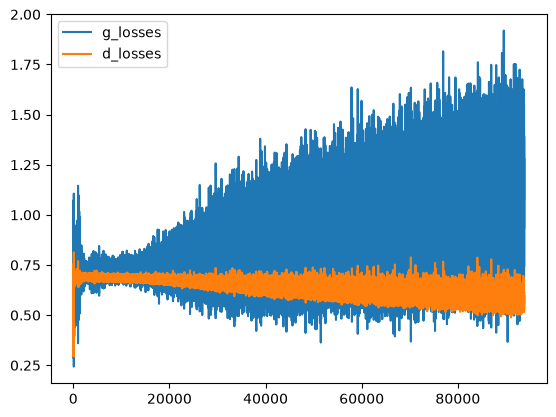

In [13]:
plt.plot(g_losses, label='g_losses')
plt.plot(d_losses, label='d_losses')
plt.legend()

The course imports `imread` from `skimage.io`, but scikit-image isn't installed
in this environment — `imageio` is, and does the same job.

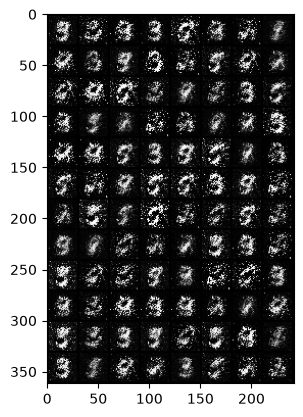

In [14]:
from imageio.v2 import imread

a = imread('gan_images/1.png')
plt.imshow(a)

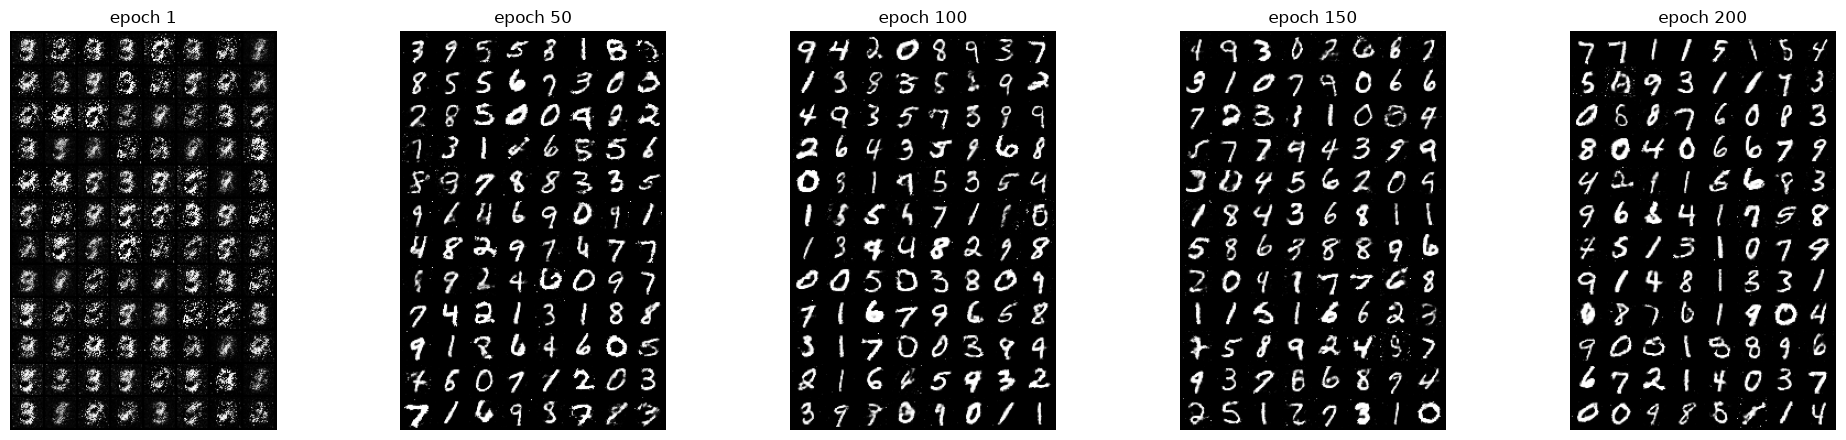

In [15]:
# Show how the samples improve over training.
# Only plot checkpoints that actually exist, so this works for any n_epochs.
checkpoints = [c for c in [1, 50, 100, 150, 200] if os.path.exists(f'gan_images/{c}.png')]

fig, axes = plt.subplots(1, len(checkpoints), figsize=(4 * len(checkpoints), 4.5))
axes = np.atleast_1d(axes)
for ax, c in zip(axes, checkpoints):
  ax.imshow(imread(f'gan_images/{c}.png'))
  ax.set_title(f'epoch {c}')
  ax.axis('off')
plt.tight_layout()
plt.show()

After epoch 1 the samples are noisy blobs; by epoch 50 they already look like
MNIST, and they keep sharpening through epoch 200.

---
# Part 2: Detecting fake images

This is the same problem as [whichfaceisreal.com](https://www.whichfaceisreal.com/):
given an image, decide whether a human photographed it or a GAN dreamed it up.

We already have a fake detector — **the Discriminator is literally trained to do
this.** Let's confirm that on MNIST first, then move to faces.

Discriminator AUC (real vs generated MNIST): 0.781
mean logit  real: +0.741   fake: -0.355


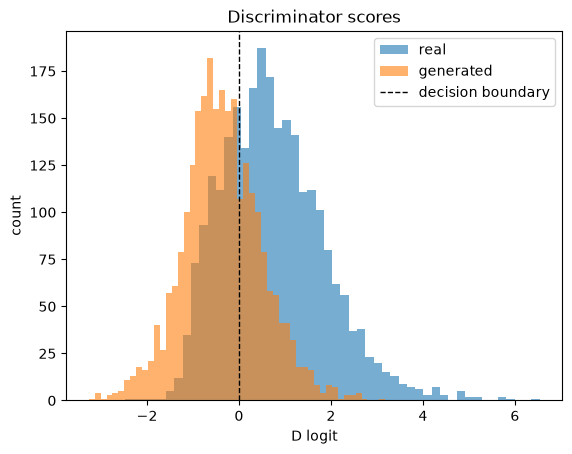

Sequential(
  (0): Linear(in_features=100, out_features=256, bias=True)
  (1): LeakyReLU(negative_slope=0.2)
  (2): BatchNorm1d(256, eps=1e-05, momentum=0.7, affine=True, bias=True, track_running_stats=True)
  (3): Linear(in_features=256, out_features=512, bias=True)
  (4): LeakyReLU(negative_slope=0.2)
  (5): BatchNorm1d(512, eps=1e-05, momentum=0.7, affine=True, bias=True, track_running_stats=True)
  (6): Linear(in_features=512, out_features=1024, bias=True)
  (7): LeakyReLU(negative_slope=0.2)
  (8): BatchNorm1d(1024, eps=1e-05, momentum=0.7, affine=True, bias=True, track_running_stats=True)
  (9): Linear(in_features=1024, out_features=784, bias=True)
  (10): Tanh()
)

In [16]:
# The Discriminator as a fake-detector, on MNIST.
from sklearn.metrics import roc_auc_score

D.eval()
G.eval()

real_scores, fake_scores = [], []
with torch.no_grad():
  for i, (inputs, _) in enumerate(data_loader):
    n = inputs.size(0)
    real_scores.append(D(inputs.reshape(n, 784).to(device)).cpu().numpy().ravel())
    fake_scores.append(D(G(torch.randn(n, latent_dim).to(device))).cpu().numpy().ravel())
    if i == 19:  # ~2560 of each is plenty
      break

real_scores = np.concatenate(real_scores)
fake_scores = np.concatenate(fake_scores)

y_mnist = np.r_[np.ones_like(real_scores), np.zeros_like(fake_scores)]
s_mnist = np.r_[real_scores, fake_scores]
print(f"Discriminator AUC (real vs generated MNIST): {roc_auc_score(y_mnist, s_mnist):.3f}")
print(f"mean logit  real: {real_scores.mean():+.3f}   fake: {fake_scores.mean():+.3f}")

plt.hist(real_scores, bins=50, alpha=0.6, label='real')
plt.hist(fake_scores, bins=50, alpha=0.6, label='generated')
plt.axvline(0, color='k', ls='--', lw=1, label='decision boundary')
plt.xlabel('D logit'); plt.ylabel('count')
plt.legend(); plt.title('Discriminator scores')
plt.show()

D.train(); G.train()

An AUC near 0.5 is actually the *goal* of GAN training — it means the generator
has become good enough that the discriminator can barely tell the difference.
A well-trained GAN destroys its own detector.

That's the core difficulty behind whichfaceisreal: the better the generator, the
harder detection becomes. Now let's try it on actual faces.

In [17]:
# Download real + GAN-generated faces.
#
#   whichfaceisreal.com serves one REAL photo (from the FFHQ dataset) and one
#   FAKE face (StyleGAN) per page load, from a public blob store.
#   thispersondoesnotexist.com serves a fresh StyleGAN face each request.
#
# We're polite: images already on disk are never re-fetched, there's a delay
# between requests, and we stop as soon as we have enough.
import re, time, requests
from glob import glob

TARGET = 60   # per class
os.makedirs('faces/real', exist_ok=True)
os.makedirs('faces/fake', exist_ok=True)

HEADERS = {'User-Agent': 'Mozilla/5.0 (educational notebook; GAN detection demo)'}
BLOB = r'https://whichfaceisreal\.blob\.core\.windows\.net/public/(?:real|fake)images/[^"]+'

n_real = len(glob('faces/real/*.jpeg'))
n_fake = len(glob('faces/fake/*.jpeg'))
print(f"already on disk: {n_real} real, {n_fake} fake")

urls_seen = set()
for _ in range(120):
    if n_real >= TARGET and n_fake >= TARGET:
        break
    try:
        html = requests.get('https://www.whichfaceisreal.com/',
                            headers=HEADERS, timeout=30).text
        for url in re.findall(BLOB, html):
            if url in urls_seen:
                continue
            urls_seen.add(url)
            is_real = 'realimages' in url
            if is_real and n_real >= TARGET:
                continue
            if not is_real and n_fake >= TARGET:
                continue
            r = requests.get(url, headers=HEADERS, timeout=30)
            if not (r.ok and r.headers.get('content-type', '').startswith('image')):
                continue
            if is_real:
                open(f'faces/real/{n_real}.jpeg', 'wb').write(r.content); n_real += 1
            else:
                open(f'faces/fake/{n_fake}.jpeg', 'wb').write(r.content); n_fake += 1
    except Exception as e:
        print('skip:', type(e).__name__)
    time.sleep(0.3)

# top up fakes from thispersondoesnotexist so the classes stay balanced
tpdne_headers = dict(HEADERS, Referer='https://thispersondoesnotexist.com/')
while n_fake < n_real:
    try:
        r = requests.get('https://thispersondoesnotexist.com/random-person.jpeg',
                         headers=tpdne_headers, timeout=30)
        if r.ok and r.headers.get('content-type', '').startswith('image'):
            open(f'faces/fake/{n_fake}.jpeg', 'wb').write(r.content); n_fake += 1
        else:
            break
    except Exception as e:
        print('skip:', type(e).__name__)
        break
    time.sleep(0.3)

print(f"total: {n_real} real and {n_fake} fake faces")

already on disk: 60 real, 60 fake
total: 60 real and 60 fake faces


60 real, 60 fake


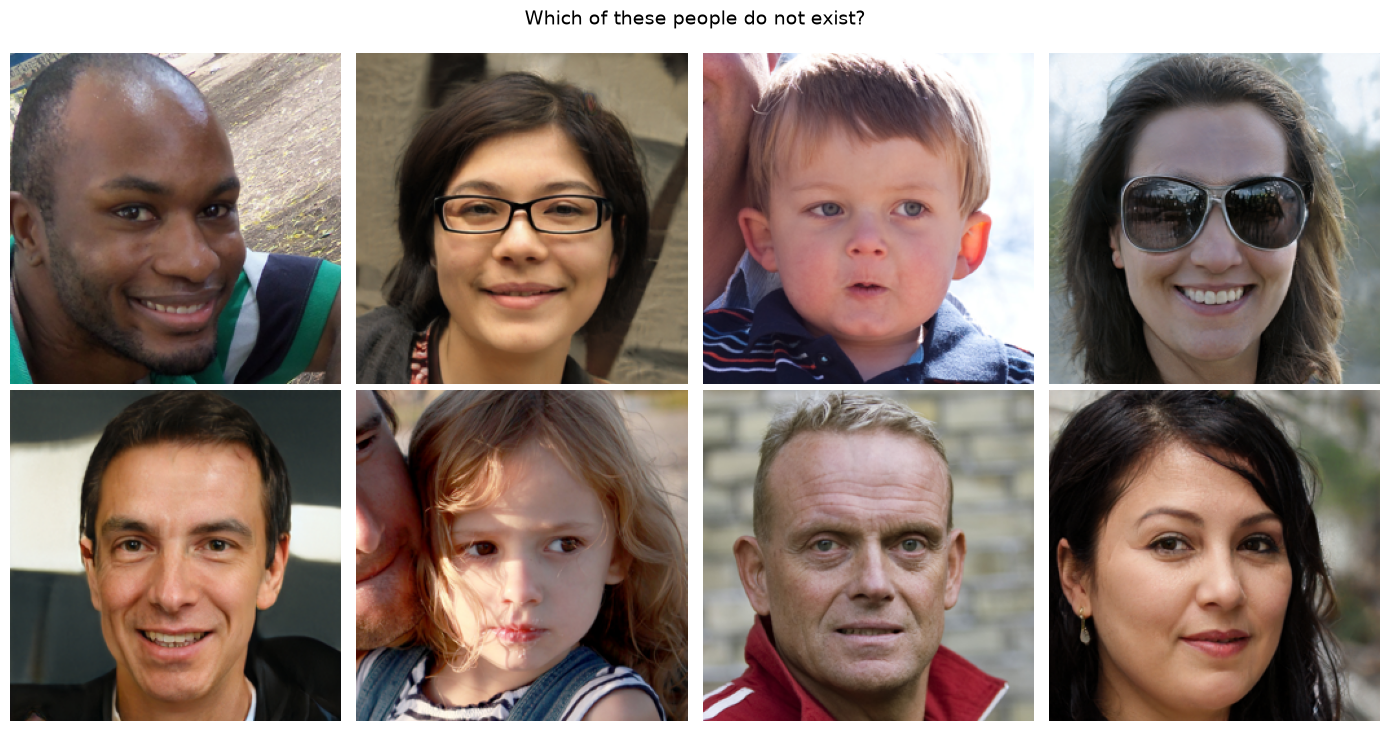

answers: ['real', 'fake', 'real', 'fake', 'fake', 'real', 'real', 'fake']


In [18]:
# The whichfaceisreal game: which of these is a real person?
from PIL import Image
from glob import glob

real_files = sorted(glob('faces/real/*.jpeg'))
fake_files = sorted(glob('faces/fake/*.jpeg'))
print(f"{len(real_files)} real, {len(fake_files)} fake")

rng = np.random.default_rng(0)
sample = [(f, 'real') for f in real_files[:4]] + [(f, 'fake') for f in fake_files[:4]]
rng.shuffle(sample)

fig, axes = plt.subplots(2, 4, figsize=(14, 7.5))
for ax, (f, label) in zip(axes.ravel(), sample):
  ax.imshow(Image.open(f).resize((256, 256)))
  ax.axis('off')
plt.suptitle('Which of these people do not exist?', fontsize=14)
plt.tight_layout()
plt.show()

print('answers:', [label for _, label in sample])

### Building an actual detector

Eyeballing is unreliable, so let's try to train one. We'll use **two independent
feature sets**, because if they agree we can trust the conclusion more than
either alone:

1. **Semantic features** — frozen VGG16, the transfer-learning trick from
   notebooks 21/22. Note this resizes to 224x224, which throws away exactly the
   high-frequency detail where GAN artifacts tend to live.
2. **Spectral features** — the azimuthally-averaged FFT power spectrum at native
   resolution. This is the classic GAN-detection signal: the up-convolution
   layers in a generator leave periodic fingerprints in the frequency domain.

With ~120 images we **must** report cross-validated accuracy. The training
accuracy of a 25088-feature model on 120 images would be 100% and meaningless.

In [19]:
from torchvision import models

try:
  vgg = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
except AttributeError:
  vgg = models.vgg16(pretrained=True)

class VGGFeatures(nn.Module):
  def __init__(self, vgg):
    super(VGGFeatures, self).__init__()
    self.vgg = vgg

  def forward(self, X):
    out = self.vgg.features(X)
    out = self.vgg.avgpool(out)
    return out.view(out.size(0), -1)

vggf = VGGFeatures(vgg).to(device).eval()

face_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

def vgg_features(paths, bs=8):
  feats = []
  with torch.no_grad():
    for i in range(0, len(paths), bs):
      batch = torch.stack([face_transform(Image.open(p).convert('RGB'))
                           for p in paths[i:i + bs]]).to(device)
      feats.append(vggf(batch).cpu().numpy())
  return np.concatenate(feats)


def azimuthal_power_spectrum(path, size=512, nbins=128):
  """1-D radial profile of the log power spectrum -- the usual GAN fingerprint."""
  img = np.array(Image.open(path).convert('L').resize((size, size)), dtype=np.float64)
  P = np.log(np.abs(np.fft.fftshift(np.fft.fft2(img)))**2 + 1e-10)
  c = size // 2
  yy, xx = np.indices((size, size))
  r = np.sqrt((xx - c)**2 + (yy - c)**2).astype(int)
  prof = (np.bincount(r.ravel(), P.ravel()) / np.bincount(r.ravel()))[:c]
  p = prof[np.linspace(0, len(prof) - 1, nbins).astype(int)]
  return (p - p.mean()) / (p.std() + 1e-9)   # normalize per image


all_files = real_files + fake_files
y = np.r_[np.ones(len(real_files)), np.zeros(len(fake_files))]

X_vgg = np.concatenate([vgg_features(real_files), vgg_features(fake_files)])
X_fft = np.array([azimuthal_power_spectrum(p) for p in all_files])

print('VGG features:     ', X_vgg.shape)
print('spectral features:', X_fft.shape)
print('labels (fake, real):', np.bincount(y.astype(int)))

# Heads-up: on this few images a large fraction of VGG's 25088 dimensions are
# constant, so we reduce with PCA before the classifier rather than feeding
# thousands of zero-variance columns to it.
print('zero-variance VGG columns:', int((X_vgg.std(axis=0) == 0).sum()), 'of', X_vgg.shape[1])

VGG features:      (120, 25088)
spectral features: (120, 128)
labels (fake, real): [60 60]
zero-variance VGG columns: 5309 of 25088


In [20]:
import warnings
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.decomposition import PCA
from sklearn.model_selection import cross_val_score, StratifiedKFold

warnings.filterwarnings('ignore')  # sklearn emits benign BLAS warnings on wide matrices

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
chance = max(y.mean(), 1 - y.mean())

vgg_clf = make_pipeline(StandardScaler(), PCA(n_components=30),
                        LogisticRegression(max_iter=5000, C=0.01))
fft_clf = make_pipeline(StandardScaler(),
                        LogisticRegression(max_iter=5000, C=1.0))

cv_results = {}
for name, clf, Xm in [('VGG16 + PCA ', vgg_clf, X_vgg),
                      ('FFT spectrum', fft_clf, X_fft)]:
  s = cross_val_score(clf, Xm, y, cv=cv, scoring='accuracy')
  cv_results[name.strip()] = s.mean()
  print(f"{name}  cv accuracy = {s.mean():.3f} +/- {s.std():.3f}   folds={np.round(s, 2)}")

print(f"\nchance level = {chance:.3f}")
print("Expect roughly 0.65-0.75 -- and note how much the individual folds swing.\n"
      "Re-running with a freshly scraped sample moves this around by several points,\n"
      "which is itself the point: this is a weak signal measured on very little data.")

VGG16 + PCA   cv accuracy = 0.667 +/- 0.099   folds=[0.71 0.54 0.62 0.62 0.83]
FFT spectrum  cv accuracy = 0.683 +/- 0.141   folds=[0.58 0.79 0.75 0.46 0.83]

chance level = 0.500
Expect roughly 0.65-0.75 -- and note how much the individual folds swing.
Re-running with a freshly scraped sample moves this around by several points,
which is itself the point: this is a weak signal measured on very little data.


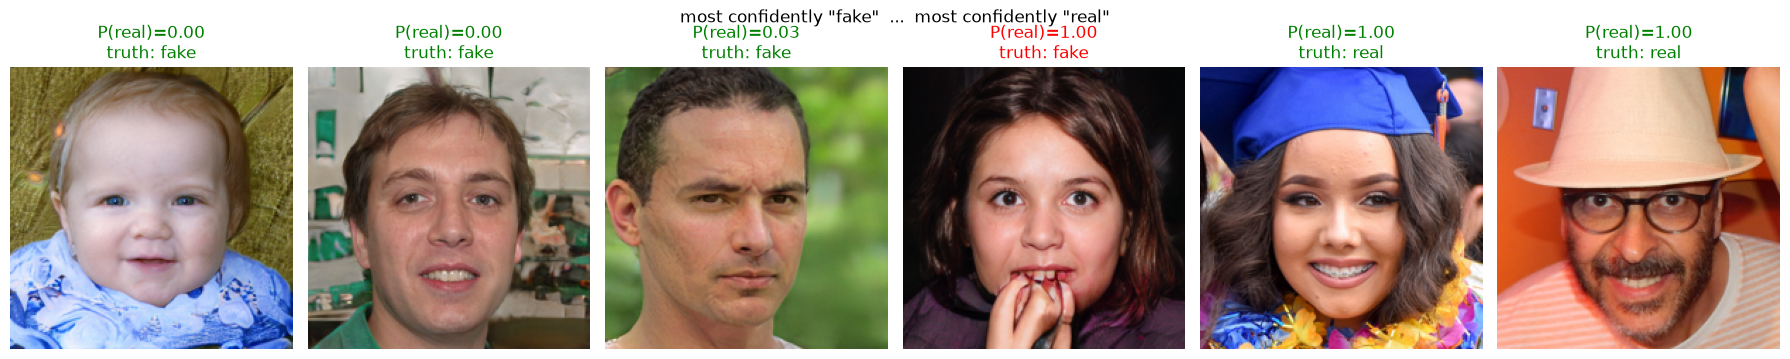

In [21]:
# Which images is the detector most / least confident about?
from sklearn.model_selection import cross_val_predict

proba = cross_val_predict(vgg_clf, X_vgg, y, cv=cv, method='predict_proba')[:, 1]
order = np.argsort(proba)

picks = list(order[:3]) + list(order[-3:])   # most "fake" and most "real"
fig, axes = plt.subplots(1, len(picks), figsize=(3 * len(picks), 3.8))
for ax, i in zip(axes, picks):
  ax.imshow(Image.open(all_files[i]).resize((200, 200)))
  truth = 'real' if y[i] == 1 else 'fake'
  correct = (proba[i] > 0.5) == (y[i] == 1)
  ax.set_title(f"P(real)={proba[i]:.2f}\ntruth: {truth}",
               color=('green' if correct else 'red'))
  ax.axis('off')
plt.suptitle('most confidently "fake"  ...  most confidently "real"')
plt.tight_layout()
plt.show()

### What to take away

**Both detectors land in the ~0.65–0.75 range — well short of useful, with
fold-to-fold swings of ±0.10 or more.** Two completely different feature sets
(semantic VGG features and native-resolution FFT spectra) landing in the same
mediocre place is informative: this isn't a bug in one pipeline, it's the actual
difficulty of the task.

That connects straight back to Part 1:

* **The Discriminator is a fake detector.** GAN training is a race between a
  forger and a detective, and a *successful* GAN drives its own discriminator
  toward chance — exactly what the MNIST AUC above shows.
* **StyleGAN wins this race against simple detectors.** These faces come from a
  generator engineered to remove the artifacts older detection methods keyed on.
  Getting meaningfully higher needs far more data and a purpose-built detector,
  not logistic regression on ~120 images.
* **So don't trust a cheap classifier to tell you what's real.** whichfaceisreal
  teaches you to hunt for specific artifacts — asymmetric earrings, mangled
  background text, odd hair boundaries, mismatched eye reflections — precisely
  because the global statistics are so well matched.

**Honest caveats.** The score is cross-validated, so it isn't inflated by
overfitting, but it comes from ~120 images, one source, one generator. It
demonstrates a *method*, not a measurement of fake-face detection in general —
that needs thousands of images spanning many generators. Also note any
difference in JPEG compression or resizing history between the real and fake
sets could leak a shortcut signal, which is a reason to be suspicious of a
*high* score here, not just a low one.

In Part 3 we'll generate faces from a different GAN and feed them to this very
detector, which tests the "it won't transfer" claim directly.

---
# Part 3: Generating fake faces ourselves

So far we've *detected* fake faces. Now let's *make* them — the same job
thispersondoesnotexist.com does.

Our Part 1 generator can't do this. It's an MLP over 784 pixels; faces at
256x256x3 are 250x more values, and a GAN that good takes days on a multi-GPU
box to train. So we load a **pretrained** one: Progressive GAN (PGAN) trained on
CelebA-HQ, from Facebook Research's GAN zoo.

It's the same idea as Part 1 — noise vector in, image out — just much bigger, and
grown progressively from 4x4 up to 256x256 during its training.

In [22]:
# Load a pretrained face GAN (~350MB on first run, then cached).
#
# Compatibility fix: pytorch_GAN_zoo is an old repo that builds its optimizers at
# load time with betas=(0, 0.99) -- an int and a float. Modern PyTorch rejects
# that with "betas must be either both floats or both Tensors", so we coerce them
# to floats for the duration of the load. We only need the generator anyway.
_orig_adam_init = torch.optim.Adam.__init__

def _patched_adam_init(self, params, lr=1e-3, betas=(0.9, 0.999), *args, **kwargs):
  betas = (float(betas[0]), float(betas[1]))
  return _orig_adam_init(self, params, lr=lr, betas=betas, *args, **kwargs)

torch.optim.Adam.__init__ = _patched_adam_init
try:
  pgan = torch.hub.load('facebookresearch/pytorch_GAN_zoo:hub', 'PGAN',
                        model_name='celebAHQ-256', pretrained=True, useGPU=False)
finally:
  torch.optim.Adam.__init__ = _orig_adam_init

print('PGAN loaded')

Using cache found in /Users/ankit/.cache/torch/hub/facebookresearch_pytorch_GAN_zoo_hub


Average network found !
PGAN loaded


generated tensor: (8, 3, 256, 256)


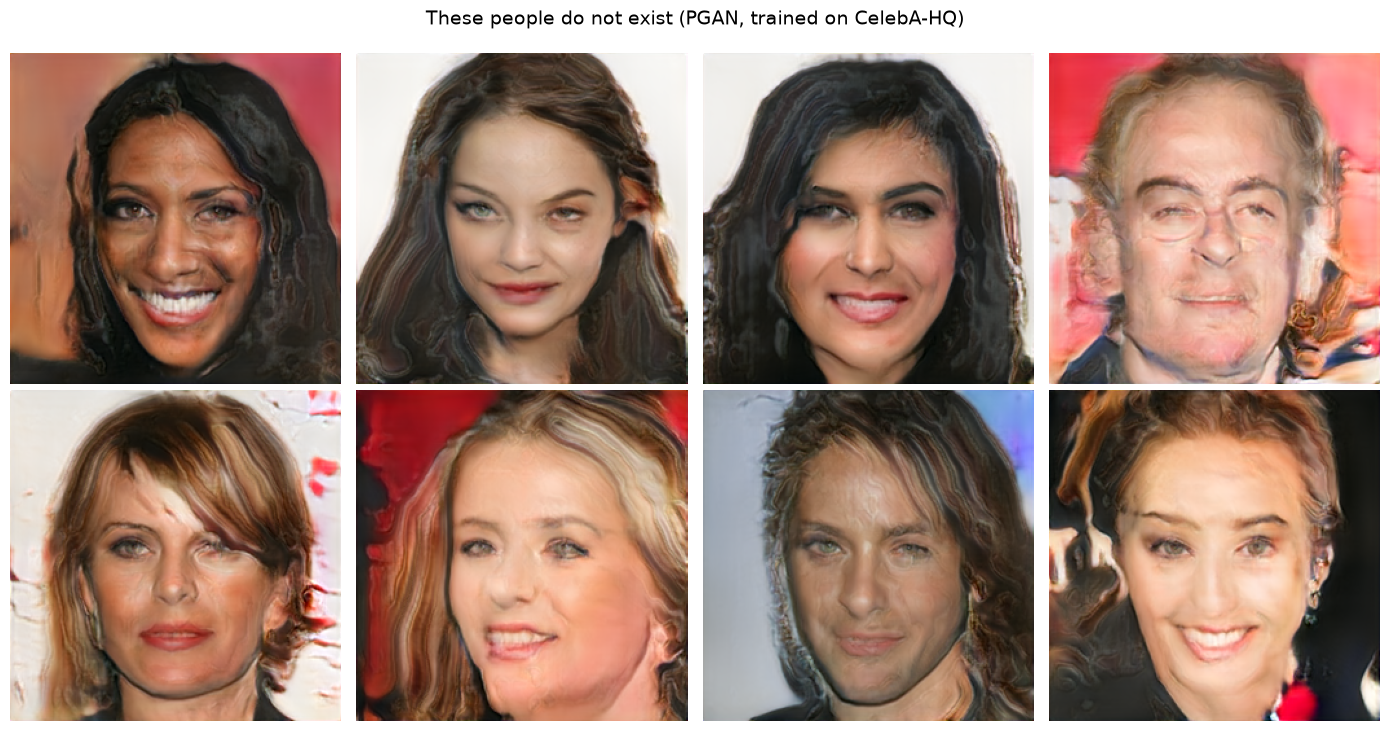

In [23]:
# Generate faces: noise in -> face out. Exactly the Part 1 idea, bigger model.
def to_displayable(batch):
  """PGAN outputs roughly [-1, 1]; map to [0, 1] for matplotlib."""
  x = (batch + 1) / 2
  return x.clamp(0, 1).permute(0, 2, 3, 1).cpu().numpy()

torch.manual_seed(0)
noise, _ = pgan.buildNoiseData(8)
with torch.no_grad():
  generated = pgan.test(noise)

print('generated tensor:', tuple(generated.shape))

imgs = to_displayable(generated)
fig, axes = plt.subplots(2, 4, figsize=(14, 7.5))
for ax, im in zip(axes.ravel(), imgs):
  ax.imshow(im)
  ax.axis('off')
plt.suptitle('These people do not exist (PGAN, trained on CelebA-HQ)', fontsize=14)
plt.tight_layout()
plt.show()

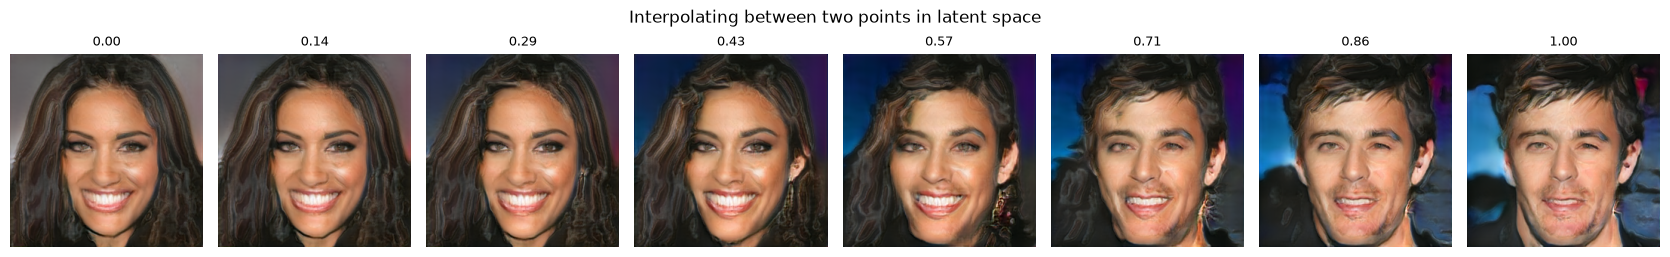

In [24]:
# Walking through latent space: the generator is a smooth function, so
# interpolating between two noise vectors morphs one face into another.
# (Try this with the Part 1 MNIST generator too -- digits morph the same way.)
torch.manual_seed(3)
z, _ = pgan.buildNoiseData(2)
alphas = np.linspace(0, 1, 8)
z_interp = torch.stack([(1 - a) * z[0] + a * z[1] for a in alphas])

with torch.no_grad():
  morph = to_displayable(pgan.test(z_interp))

fig, axes = plt.subplots(1, len(alphas), figsize=(2.1 * len(alphas), 2.6))
for ax, im, a in zip(axes, morph, alphas):
  ax.imshow(im)
  ax.set_title(f'{a:.2f}', fontsize=9)
  ax.axis('off')
plt.suptitle('Interpolating between two points in latent space')
plt.tight_layout()
plt.show()

### Cross-generator test

Now we can actually test the claim from Part 2 — that a detector trained on one
generator doesn't transfer to another.

The Part 2 detector only ever saw **StyleGAN** fakes (from whichfaceisreal). The
faces we just made come from **PGAN**, a different architecture trained on a
different dataset. Every one of them is fake, so a detector that generalizes
should label them all fake.

We save them as JPEGs first so they go through exactly the same preprocessing
path as the Part 2 images — otherwise we'd be measuring a compression artifact
rather than the generator.

In [25]:
# Make a batch of PGAN faces and save them as JPEGs
os.makedirs('faces/pgan', exist_ok=True)

torch.manual_seed(123)
noise, _ = pgan.buildNoiseData(24)
with torch.no_grad():
  pgan_batch = to_displayable(pgan.test(noise))

pgan_files = []
for i, im in enumerate(pgan_batch):
  path = f'faces/pgan/{i}.jpeg'
  Image.fromarray((im * 255).astype(np.uint8)).save(path, quality=95)
  pgan_files.append(path)

# Fit the Part 2 detector on ALL of its data, then apply it to the PGAN faces.
vgg_clf.fit(X_vgg, y)
X_pgan = vgg_features(pgan_files)
p_real = vgg_clf.predict_proba(X_pgan)[:, 1]

caught = (p_real < 0.5).sum()
print(f"PGAN faces flagged as fake: {caught}/{len(pgan_files)} "
      f"({caught / len(pgan_files):.0%})")
print(f"mean P(real) assigned to these known fakes: {p_real.mean():.2f}")
print(f"\nOn its own StyleGAN data this detector scored "
      f"{cv_results['VGG16 + PCA']:.2f} in cross-validation.")
print("Every image here is fake, so anything below 100% is a miss -- and a score\n"
      "under 50% means it is worse than a coin flip on this generator.")

PGAN faces flagged as fake: 9/24 (38%)
mean P(real) assigned to these known fakes: 0.66

On its own StyleGAN data this detector scored 0.67 in cross-validation.
Every image here is fake, so anything below 100% is a miss -- and a score
under 50% means it is worse than a coin flip on this generator.


### Putting it together

Three things, in one notebook:

1. **Part 1 — train a GAN.** Two MLPs playing a minimax game turn noise into
   MNIST digits in ~200 epochs.
2. **Part 2 — detect fakes.** The Discriminator *is* a detector. On real
   StyleGAN faces, two independent feature sets both stall in the ~0.65–0.75
   range. Modern face GANs are hard to catch with simple methods.
3. **Part 3 — generate fakes.** A pretrained PGAN produces faces of people who
   don't exist, and its latent space is smooth enough to morph between them.

The cross-generator result above is the punchline. The detector was tuned to
StyleGAN's fingerprints; shown PGAN's output it catches only a fraction, and
confidently labels most of those known fakes as *real*. A detector that scores
respectably on the generator it was trained on can be near-useless — even
actively misleading — on the next one.

That asymmetry, generation improving faster than detection, is the practical
reality behind sites like whichfaceisreal.

**Ethics note.** Generated faces are genuinely useful (privacy-preserving test
data, avatars, augmentation), but the same tools drive fraudulent profiles and
non-consensual imagery. Label synthetic media as synthetic, and don't lean on a
classifier like this one to decide whether a real person's photo is authentic.